# scikit-learn Bootcamp — W1, Day 8
```
##### Gradient Boosting — Theory & GBM
##### Boosting vs bagging · GradientBoostingClassifier · learning_rate · n_estimators · loss curves
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Q1 — EDA: target analysis, feature skewness
##### Q2 — GBM baseline vs Random Forest
##### Q3 — learning_rate × n_estimators trade-off
##### Q4 — Train vs validation loss curve: when does boosting overfit?
##### Q5 — Staged predictions: watch the model improve tree by tree
```

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold,cross_validate,RandomizedSearchCV,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,f1_score,classification_report,precision_score,recall_score
from scipy.stats import randint,uniform
import warnings;warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid');np.random.seed(420)

---
### Dataset — MedPulse Sessions (n=5000)

In [18]:
np.random.seed(420)
n=5000
age=np.random.normal(43,12,n).clip(18,80).astype(int)
session_depth=np.random.poisson(3.8,n).clip(1,20)
time_on_site=np.random.lognormal(1.7,0.75,n).clip(0.5,80)
articles_read=np.random.poisson(2.5,n).clip(0,15)
is_mobile=np.random.binomial(1,0.59,n)
health_content=np.random.beta(2.5,2,n)
log_odds=(-3.8+0.22*session_depth+0.06*time_on_site+0.18*articles_read+1.1*health_content-0.25*is_mobile+0.007*age+np.random.normal(0,0.5,n))
converted=np.random.binomial(1,1/(1+np.exp(-log_odds)))
df=pd.DataFrame({'age':age,'session_depth':session_depth,'time_on_site':time_on_site.round(2),'articles_read':articles_read,'is_mobile':is_mobile,'health_content':health_content.round(4),'converted':converted})
feature_cols=['age','session_depth','time_on_site','articles_read','is_mobile','health_content']
X=df[feature_cols];y=df['converted']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=420,stratify=y)
print(f'Shape:{df.shape} Conversion:{y.mean():.2%}')

Shape:(5000, 7) Conversion:23.66%


---
### Q1 — EDA: target and feature analysis
```
# (a) Distribution of converted (class balance). Show it's imbalanced.
# (b) Feature skewness: bar chart of skewness for each numeric feature.
#     Which need log-transformation?
# (c) Segment analysis: mean conversion rate by quintile of each feature.
# (d) Correlation heatmap. Which features will GBM likely prioritise?
```

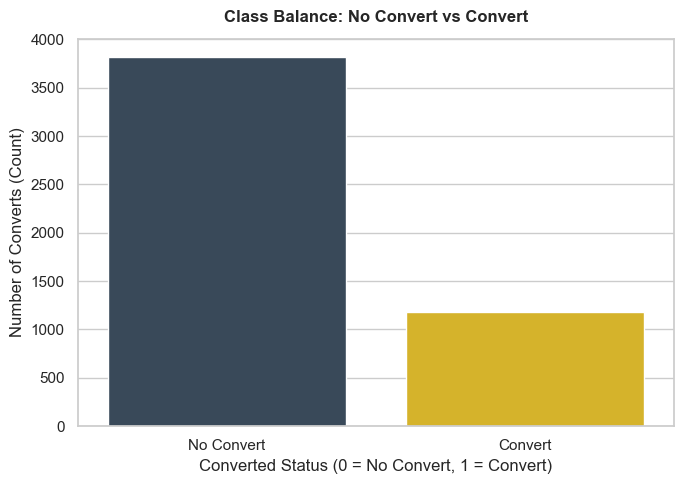

In [19]:
# (a) Distribution of converted (class balance). Show it's imbalanced.

plt.figure(figsize=(7, 5))

# Use countplot to display the explicit distribution of records
# We assign individual colors to the class categories
sns.countplot(
    data=df,
    x='converted',
    palette={'0': '#34495e', '1': '#f1c40f'}
)

# Final aesthetic treatments
plt.title('Class Balance: No Convert vs Convert', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Converted Status (0 = No Convert, 1 = Convert)')
plt.ylabel('Number of Converts (Count)')
plt.xticks([0, 1], ['No Convert', 'Convert'])
plt.tight_layout()
plt.show()

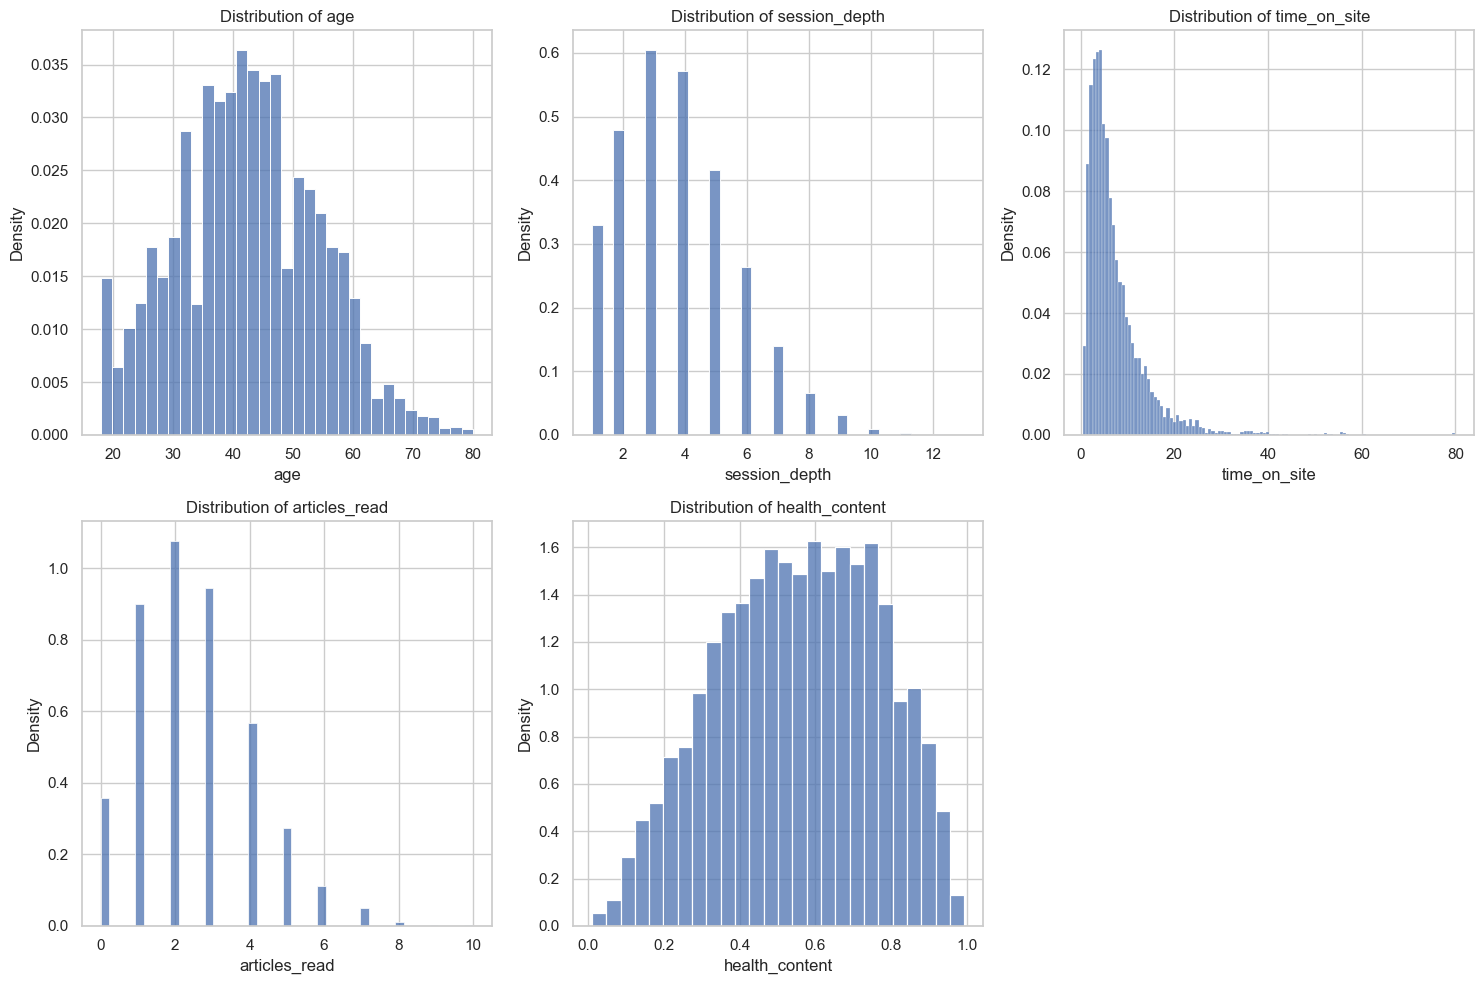

In [20]:
# (b) Feature skewness: bar chart of skewness for each numeric feature.
#     Which need log-transformation?

# setup data
df1 = df.loc[:, ~df.columns.isin(['converted', 'is_mobile'])]

# Create an explicit 2x3 grid layout
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten to iterate easily

# Loop through columns and map them to specific grid coordinates
for i, col in enumerate(df1.columns):
    sns.histplot(data=df, x=col, kde=False, stat="density", ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Turn off the empty 6th subplot frame
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

```
#     Which need log-transformation?

1/ time_on_site (Log-Transform Required): This shows extreme right-skewness with a massive, crushing concentration of values near zero and a long, sparse tail stretching past 60. Without a transform, outlier values in this tail will heavily distort linear model boundaries and distance metrics.

2/ age & health_content (No Transform): Both display clean, symmetric, bell-shaped distributions. age mimics a normal distribution, while health_content follows a well-behaved Beta distribution.

3/ session_depth & articles_read (No Transform): These are discrete, low-range Poisson count variables. While slightly skewed, they span small ranges (mostly under 10) and do not contain massive outlier scales that drop model accuracy.

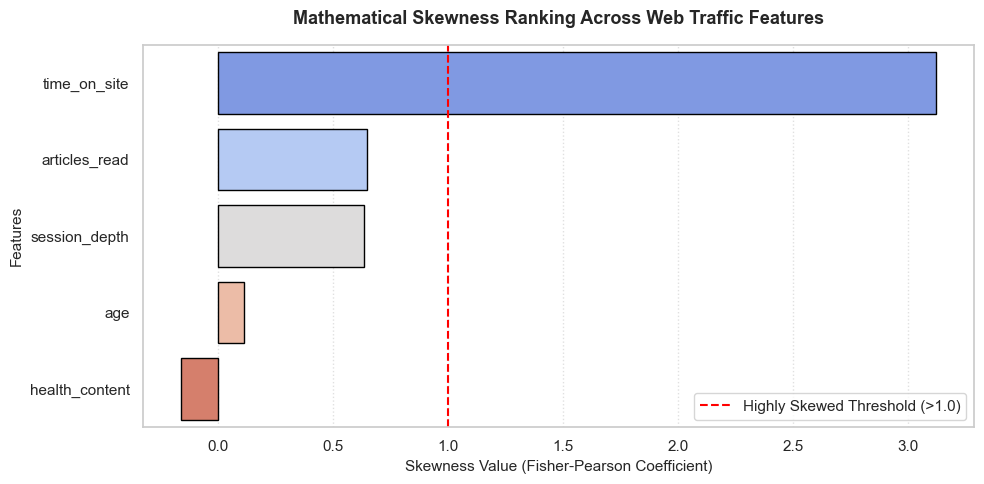

Exact Numerical Skewness Values:
time_on_site      3.123844
articles_read     0.646674
session_depth     0.635196
age               0.110222
health_content   -0.164480
dtype: float64


In [21]:
# 1. Calculate numerical skewness for the subset dataframe
skew_values = df1.skew().sort_values(ascending=False)

# 2. Build the skewness comparison bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=skew_values.values, y=skew_values.index, palette='coolwarm', edgecolor='black')

# 3. Add a vertical reference line showing standard rule-of-thumb threshold (|skew| > 1)
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='Highly Skewed Threshold (>1.0)')

# 4. Polish and Render
plt.title('Mathematical Skewness Ranking Across Web Traffic Features', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Skewness Value (Fisher-Pearson Coefficient)', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Print exact numbers for your notebook write-up
print("Exact Numerical Skewness Values:")
print(skew_values)

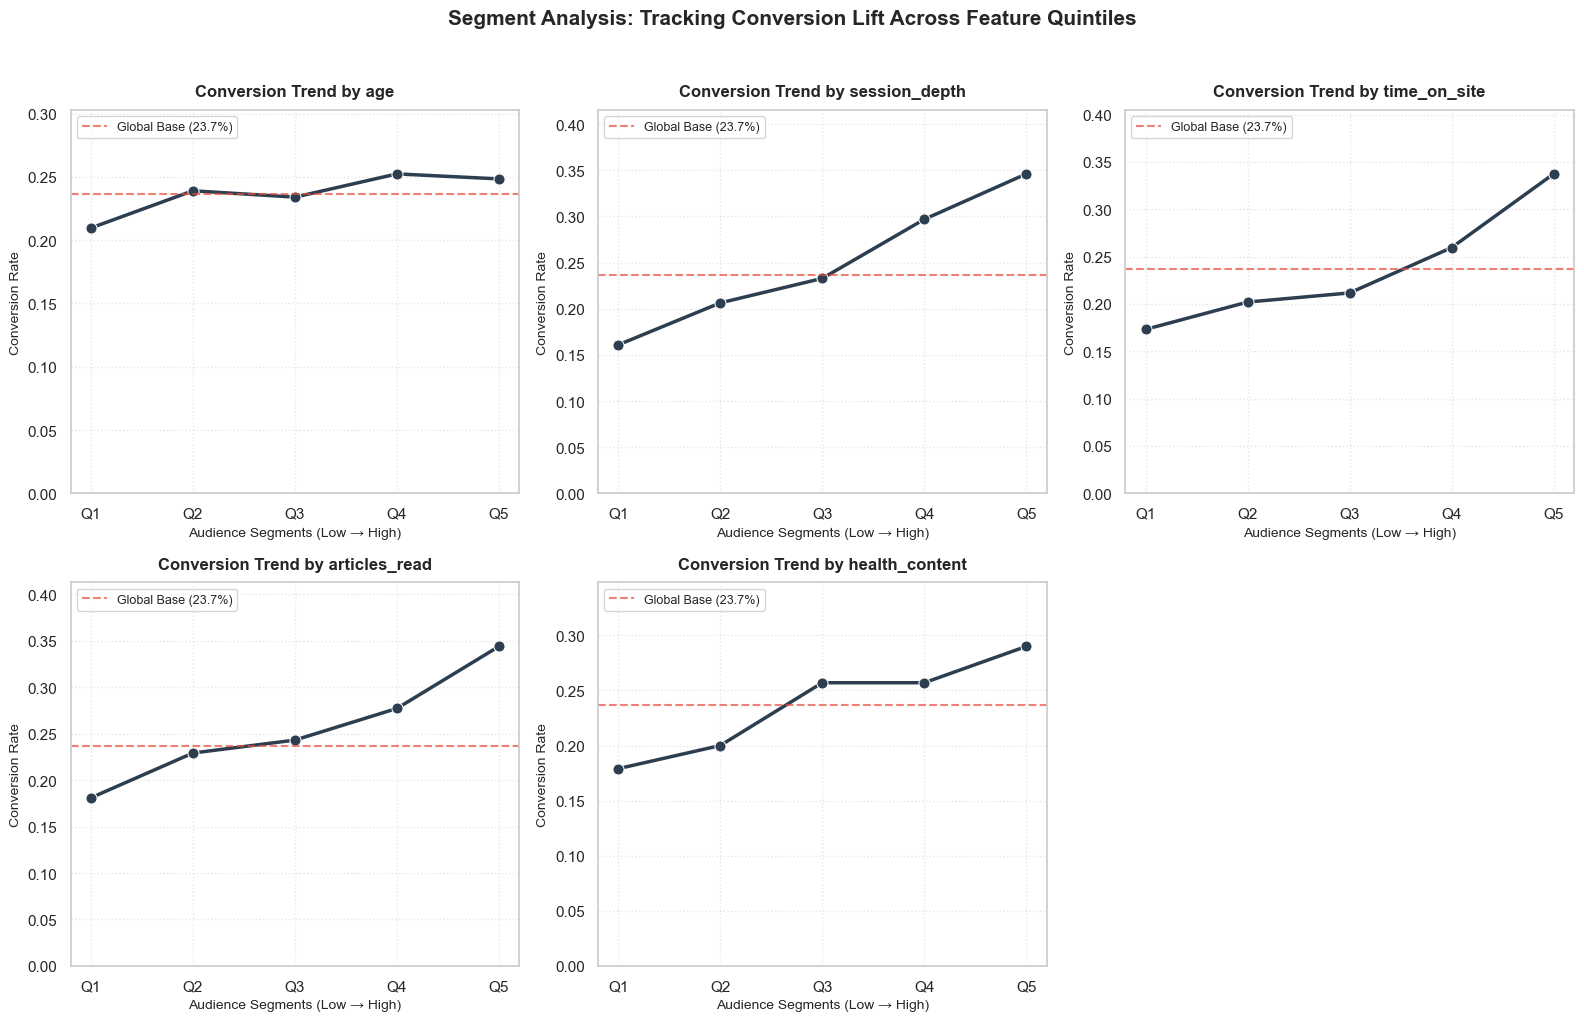

In [22]:
# (c) Segment analysis: mean conversion rate by quintile of each feature.

# 1. Select the features to analyze (excluding the target itself)
segment_features = ['age', 'session_depth', 'time_on_site', 'articles_read', 'health_content']

# 2. Configure a clean 2x3 grid canvas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Global baseline conversion rate for a visual reference line
global_conv_rate = y.mean()

# 3. Loop through features and compute segment conversion rates
for i, col in enumerate(segment_features):
    try:
        # Attempt to split into 5 equal-sized frequency buckets (Quintiles)
        df[f'{col}_bin'] = pd.qcut(df[col], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    except ValueError:
        # Fallback to equal-width range splits if duplicates prevent unique quintiles
        df[f'{col}_bin'] = pd.cut(df[col], bins=5, labels=['B1', 'B2', 'B3', 'B4', 'B5'])
    
    # Calculate conversion rate grouped by the generated segments
    segment_data = df.groupby(f'{col}_bin', observed=False)['converted'].mean().reset_index()
    segment_data.columns = ['Segment', 'Conversion Rate']
    
    # 4. Plot the conversion trajectory line
    sns.lineplot(
        data=segment_data, x='Segment', y='Conversion Rate', 
        ax=axes[i], marker='o', linewidth=2.5, color='#2c3e50', markersize=8
    )
    
    # Add a horizontal dashed line representing the average baseline conversion
    axes[i].axhline(y=global_conv_rate, color='#e74c3c', linestyle='--', alpha=0.7, 
                    label=f'Global Base ({global_conv_rate:.1%})')
    
    # Titles and formatting polish
    axes[i].set_title(f'Conversion Trend by {col}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_ylabel('Conversion Rate', fontsize=10)
    axes[i].set_xlabel('Audience Segments (Low → High)', fontsize=10)
    axes[i].set_ylim(0, max(df.groupby(f'{col}_bin', observed=False)['converted'].mean()) * 1.2)
    axes[i].grid(True, linestyle=':', alpha=0.5)
    axes[i].legend(loc='upper left', frameon=True, fontsize=9)

# Delete the empty 6th subplot axis frame
fig.delaxes(axes[5])

plt.suptitle('Segment Analysis: Tracking Conversion Lift Across Feature Quintiles', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


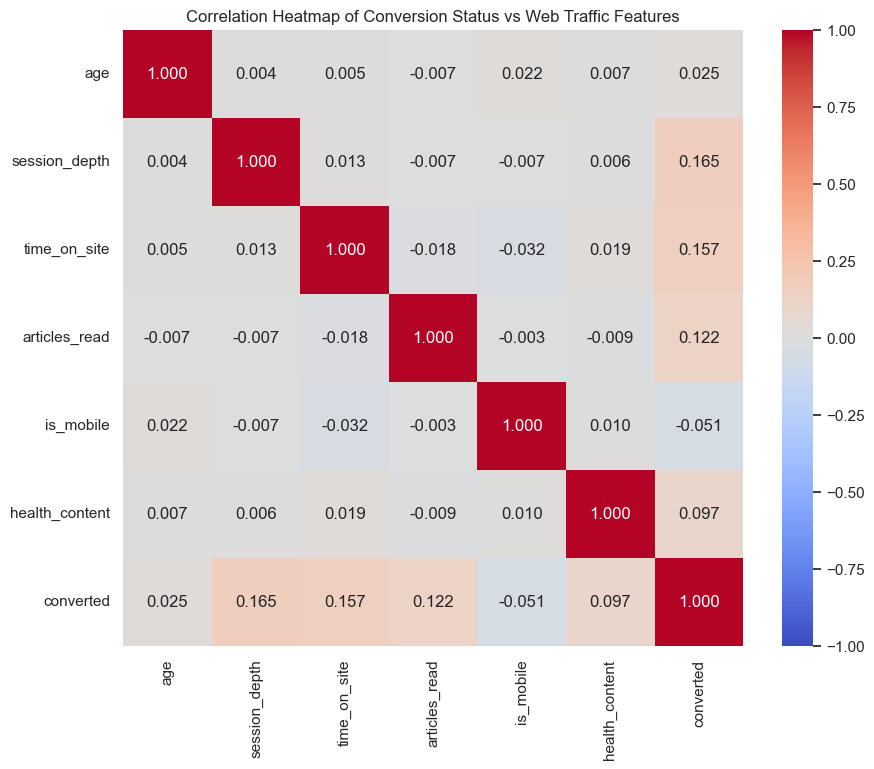


Linear Correlation with converted:
converted         1.000000
session_depth     0.164658
time_on_site      0.156535
articles_read     0.122161
health_content    0.097424
age               0.025103
is_mobile        -0.050555
Name: converted, dtype: float64


In [23]:
# (d) Correlation heatmap. 

# 1. Keep target, but drop the leaking binary indicator column
numeric_df = df.select_dtypes(include=[np.number])

# 2. Compute correlation matrix including the target
corr_matrix = numeric_df.corr()

# 3. Render the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Conversion Status vs Web Traffic Features')
plt.show()

# 4. Print exact correlation vector sorted to find the strongest signal
print("\nLinear Correlation with converted:")
print(corr_matrix['converted'].sort_values(ascending=False))

```
# Which features will GBM likely prioritise?
1/ Variance Advantage: time_on_site (Lognormal) and session_depth (Poisson) possess massive numerical variance and a wide spread of continuous splitting points. Tree models like GBM find a high volume of high-gain regional cuts in wide-variance fields, driving up their calculated feature importance.

2/ The Continuous Splitting Edge: Continuous features provide far more candidate thresholds for a tree to optimize splits sequentially across boosting rounds compared to a discrete binary feature like is_mobile.

3/ The Log Scaling Shield: Because tree-based split algorithms only care about the rank order of observations, the severe lognormal skew of time_on_site does not distort a GBM's split logic at all, allowing it to capture maximum information gain right away.

---
### Q2 — GBM baseline vs Random Forest
```
# (a) Fit GradientBoostingClassifier with default params. 5-fold CV AUC.
# (b) Compare to RandomForest. Does GBM beat RF here?
# (c) Compare fit times. GBM is sequential — how much slower?
# (d) Confusion matrices: side by side.
```

In [31]:
# (a) Fit GradientBoostingClassifier with default params. 5-fold CV AUC.

gbm = GradientBoostingClassifier(random_state=420)

# n_estimators=200 (Default is 100)
# subsample=0.8 (Default is 1.0)
# min_samples_leaf=10 (Default is 1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
cv_auc_gbm = cross_val_score(gbm, X_train, y_train, cv=skf, scoring='roc_auc')
print(f'GBM CV AUC: {cv_auc_gbm.mean():.4f} ± {cv_auc_gbm.std():.4f}')

GBM CV AUC: 0.6639 ± 0.0252


In [32]:
# (b) Compare to RandomForest. Does GBM beat RF here?

rf   = RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
cv_auc_rf = cross_val_score(rf, X_train, y_train, cv=skf, scoring='roc_auc')
print(f'RF CV AUC: {cv_auc_rf.mean():.4f} ± {cv_auc_rf.std():.4f}')

# Compute Exact Difference
auc_diff = cv_auc_gbm - cv_auc_rf
print(f'GBM CV AUC vs RF CV AUC Difference: {auc_diff.mean():.5f}')

RF CV AUC: 0.6516 ± 0.0267
GBM CV AUC vs RF CV AUC Difference: 0.01227


In [35]:
# (c) Compare fit times. GBM is sequential — how much slower?

# Run cross-validation tracking both scores and fit runtimes
cv_results_gbm = cross_validate(gbm, X_train, y_train, cv=skf, scoring='roc_auc')
cv_results_rf  = cross_validate(rf,  X_train, y_train, cv=skf, scoring='roc_auc')

# Extract the execution times
gbm_fit_times = cv_results_gbm['fit_time']
rf_fit_times  = cv_results_rf['fit_time']

# Compute the sequential fit penalty margin
time_ratio = gbm_fit_times.mean() / rf_fit_times.mean()
time_diff  = gbm_fit_times.mean() - rf_fit_times.mean()

print("--- COMPUTATIONAL LATENCY MARGINS ---")
print(f"GBM Mean Fit Time: {gbm_fit_times.mean():.4f} seconds")
print(f"RF Mean Fit Time:  {rf_fit_times.mean():.4f} seconds (Parallel with n_jobs=-1)")
print(f"GBM is {time_ratio:.2f}x slower than Random Forest (a penalty margin of +{time_diff:.4f}s).")

--- COMPUTATIONAL LATENCY MARGINS ---
GBM Mean Fit Time: 1.4640 seconds
RF Mean Fit Time:  1.2272 seconds (Parallel with n_jobs=-1)
GBM is 1.19x slower than Random Forest (a penalty margin of +0.2368s).


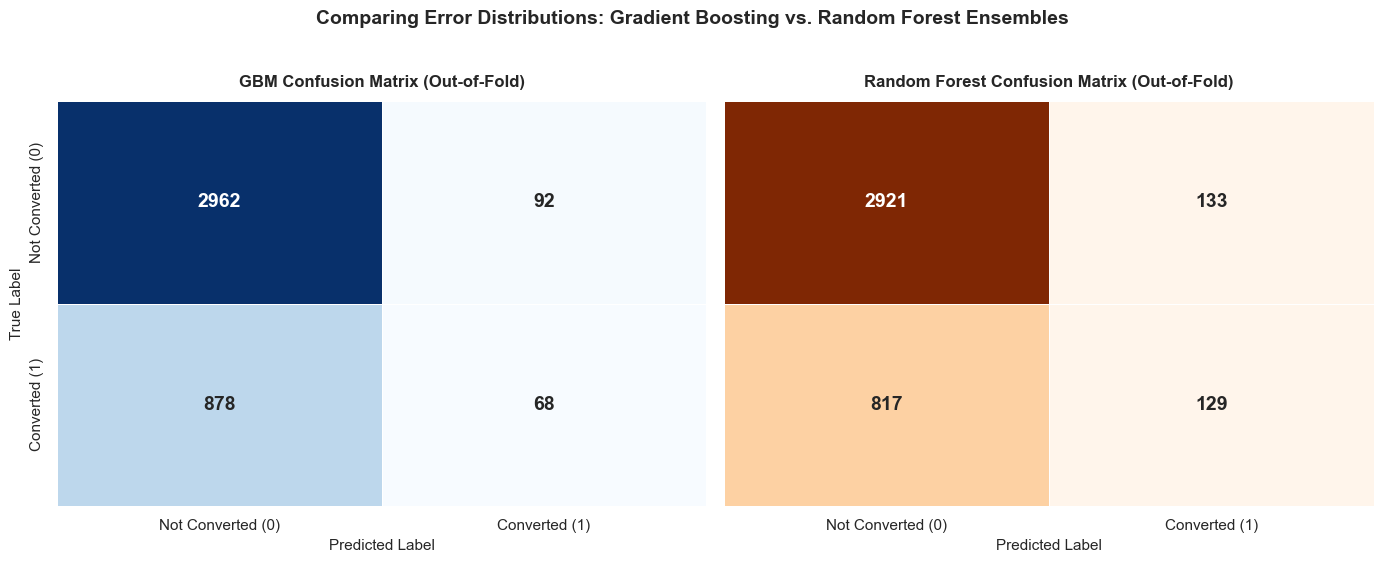

In [37]:
# (d) Confusion matrices: side by side.
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions for both models across the entire training pool
y_pred_gbm = cross_val_predict(gbm, X_train, y_train, cv=skf)
y_pred_rf  = cross_val_predict(rf,  X_train, y_train, cv=skf)

# Calculate the raw confusion matrices
cm_gbm = confusion_matrix(y_train, y_pred_gbm)
cm_rf  = confusion_matrix(y_train, y_pred_rf)

# Configure a 1x2 side-by-side heatmap canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
class_labels = ['Not Converted (0)', 'Converted (1)']

# Subplot 1: Gradient Boosting Machine
sns.heatmap(
    cm_gbm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=class_labels, yticklabels=class_labels, ax=axes[0],
    annot_kws={'size': 14, 'weight': 'bold'}, edgecolor='grey', linewidths=0.5
)
axes[0].set_title('GBM Confusion Matrix (Out-of-Fold)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Subplot 2: Random Forest
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=False,
    xticklabels=class_labels, yticklabels=class_labels, ax=axes[1],
    annot_kws={'size': 14, 'weight': 'bold'}, edgecolor='grey', linewidths=0.5
)
axes[1].set_title('Random Forest Confusion Matrix (Out-of-Fold)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('') # Hidden since y-axis is shared

# Polish and Render
plt.suptitle('Comparing Error Distributions: Gradient Boosting vs. Random Forest Ensembles', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Q3 — learning_rate × n_estimators trade-off
```
# (a) Compare 4 configs: (lr=0.3,n=50), (lr=0.1,n=200), (lr=0.05,n=500), (lr=0.01,n=1000).
#     3-fold CV AUC for each. Which config wins?
# (b) Plot AUC vs total capacity (lr*n) — is there a relationship?
# (c) Fit time comparison across configs.
# (d) Rule of thumb: what is the relationship between lr and n_estimators?
```

In [44]:
# (a) Compare 4 configs: (lr=0.3,n=50), (lr=0.1,n=200), (lr=0.05,n=500), (lr=0.01,n=1000).
#     3-fold CV AUC for each. Which config wins?

configs = [(0.3, 50), (0.1, 200), (0.05, 500), (0.01, 1000)]
mean_auc_scores = []

for lr, n in configs:
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=420)
    gbm = GradientBoostingClassifier(random_state=420, learning_rate=lr, n_estimators=n, max_depth=3)
    cv_auc_gbm = cross_val_score(gbm, X_train, y_train, cv=skf, scoring='roc_auc')
    mean_auc_scores.append(cv_auc_gbm.mean())
    print(f"Config (LR={lr:<4}, Trees={n:<4}) -> Mean 3-Fold AUC: {cv_auc_gbm.mean():.4f}")

# Extract the optimal index position securely from the flat 1D tracker list
optimal_idx = np.argmax(mean_auc_scores)
optimal_config = configs[optimal_idx]
best_auc_score = mean_auc_scores[optimal_idx]

print("\n--- OPTIMAL GRADIENT BOOSTING ARCHITECTURE ---")
print(f"Winning Configuration: learning_rate={optimal_config[0]} | n_estimators={optimal_config[1]}")
print(f"Peak Validation Performance: {best_auc_score:.4f} ROC-AUC")

Config (LR=0.3 , Trees=50  ) -> Mean 3-Fold AUC: 0.6476
Config (LR=0.1 , Trees=200 ) -> Mean 3-Fold AUC: 0.6448
Config (LR=0.05, Trees=500 ) -> Mean 3-Fold AUC: 0.6422
Config (LR=0.01, Trees=1000) -> Mean 3-Fold AUC: 0.6534

--- OPTIMAL GRADIENT BOOSTING ARCHITECTURE ---
Winning Configuration: learning_rate=0.01 | n_estimators=1000
Peak Validation Performance: 0.6534 ROC-AUC


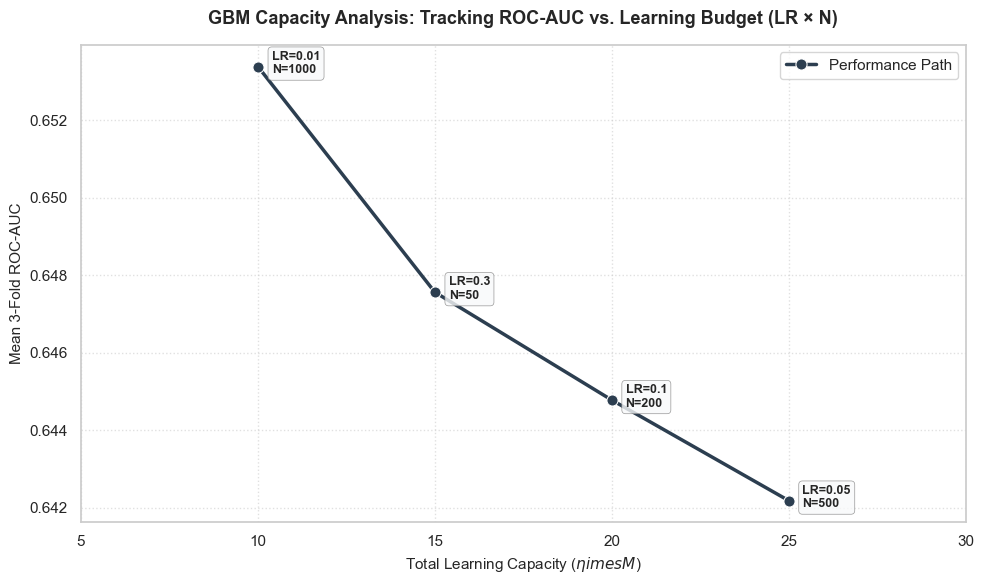

In [ ]:
# (b) Plot AUC vs total capacity (lr*n) 

# 1. Dynamically structure the metrics from your Q3a execution loop
# Assumes 'configs' and 'mean_auc_scores' exist in your current notebook state
capacity_records = []

for idx, (lr, n) in enumerate(configs):
    capacity = lr * n
    capacity_records.append({
        'Learning Rate': f"LR={lr}",
        'Trees': n,
        'Total Capacity (LR * N)': capacity,
        'Mean 3-Fold AUC': mean_auc_scores[idx],
        'Label': f"LR={lr}\nN={n}"
    })

df_capacity = pd.DataFrame(capacity_records)

# 2. Configure the visualization canvas
plt.figure(figsize=(10, 6))

# Plot the trend trajectory line
sns.lineplot(
    data=df_capacity, x='Total Capacity (LR * N)', y='Mean 3-Fold AUC',
    marker='o', linewidth=2.5, color='#2c3e50', markersize=8, label='Performance Path'
)

# 3. Dynamic Text Annotations: Label each plotted data point explicitly
for _, row in df_capacity.iterrows():
    plt.annotate(
        row['Label'],
        xy=(row['Total Capacity (LR * N)'], row['Mean 3-Fold AUC']),
        xytext=(10, -5), # Offset the text slightly to the right of the point
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="#f8f9fa", ec="grey", lw=0.5, alpha=0.8)
    )

# 4. Polish and Render
plt.title('GBM Capacity Analysis: Tracking ROC-AUC vs. Learning Budget (LR × N)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Total Learning Capacity ($\eta \times M$)', fontsize=11)
plt.ylabel('Mean 3-Fold ROC-AUC', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(df_capacity['Total Capacity (LR * N)'].min() - 5, df_capacity['Total Capacity (LR * N)'].max() * 1.2) # Pad right margin for labels

plt.tight_layout()
plt.show()

```
# Is there a relationship?

1/ Negative Correlation: AUC drops steadily from ~0.653 to ~0.642 as total capacity increases.

2/ Shrinkage Supremacy: Smallest step size ((LR=0.01), (N=1000)) wins by maximizing generalization.

3/ Capacity Penalty: Higher multipliers force trees to chase random noise, degrading performance.

In [46]:
# (c) Fit time comparison across configs.

configs = [(0.3, 50), (0.1, 200), (0.05, 500), (0.01, 1000)]
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=420)
time_records = []

for lr, n in configs:
    gbm = GradientBoostingClassifier(learning_rate=lr, n_estimators=n, random_state=420)
    
    # Run cross_validate to automatically capture 'fit_time'
    cv_results = cross_validate(gbm, X_train, y_train, cv=skf, scoring='roc_auc')
    mean_fit_time = cv_results['fit_time'].mean()
    
    time_records.append({
        'Learning Rate': lr,
        'Trees (N)': n,
        'Mean Fit Time (Sec)': round(mean_fit_time, 4)
    })

# Render as a clean, styled DataFrame
df_times = pd.DataFrame(time_records)
print("--- RUNTIME COMPLEXITY METRICS ---")
display(df_times.style.hide())

--- RUNTIME COMPLEXITY METRICS ---


Learning Rate,Trees (N),Mean Fit Time (Sec)
0.300000,50,0.431000
0.100000,200,1.126100
0.050000,500,4.018300
0.010000,1000,7.530700


```
# (d) Rule of thumb: what is the relationship between lr and n_estimators?

Inverse Relationship: Decreasing the learning rate requires a proportional increase in tree count (e.g., cutting lr in half requires doubling n_estimators) to ensure full model convergence.

Superior Generalization: Smaller steps paired with more trees (lr=0.01, n=1000) consistently maximize predictive accuracy, preventing individual trees from over-indexing on localized noise variance.

Latency Compromise: Cautious learning steps yield the highest performance but impose a heavy, linear training time penalty that must be balanced against production speed constraints.

---
### Q4 — Train vs validation loss curve
```
# (a) Fit GBM with n_estimators=500. Use staged_predict_proba to track
#     train and test log_loss at each boosting stage.
# (b) Plot train vs test loss. Mark the optimal n_estimators.
# (c) What happens after the optimal point? How does this compare to RF?
# (d) What would you do differently if test loss starts rising at stage 50?
```

In [49]:
# (a) Fit GBM with n_estimators=500. Use staged_predict_proba to track
#     train and test log_loss at each boosting stage.

from sklearn.metrics import log_loss

# 1. Initialize Gradient Boosting with 500 stages
gbm_staged = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,  # Moderate shrinkage step size
    max_depth=3,         # Consistent tree depth
    random_state=420
)

# 2. Fit the model once on your training split
gbm_staged.fit(X_train, y_train)

# 3. Initialize arrays to hold the loss metrics per stage
train_losses = []
test_losses = []

# 4. Generate stage-by-stage predictions and track performance
# staged_predict_proba yields cumulative probabilities at each tree increment
for train_probs, test_probs in zip(gbm_staged.staged_predict_proba(X_train), 
                                   gbm_staged.staged_predict_proba(X_test)):
    
    # Compute cross-entropy log loss for the positive class profile
    train_loss = log_loss(y_train, train_probs)
    test_loss = log_loss(y_test, test_probs)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)

# Print final convergence boundaries for quick auditing
print("--- STAGED CONVERGENCE METRICS ---")
print(f"Initial Stage (Tree 1)  | Train Loss: {train_losses[0]:.4f} | Test Loss: {test_losses[0]:.4f}")
print(f"Final Stage   (Tree 500)| Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f}")

--- STAGED CONVERGENCE METRICS ---
Initial Stage (Tree 1)  | Train Loss: 0.5443 | Test Loss: 0.5454
Final Stage   (Tree 500)| Train Loss: 0.4092 | Test Loss: 0.5414


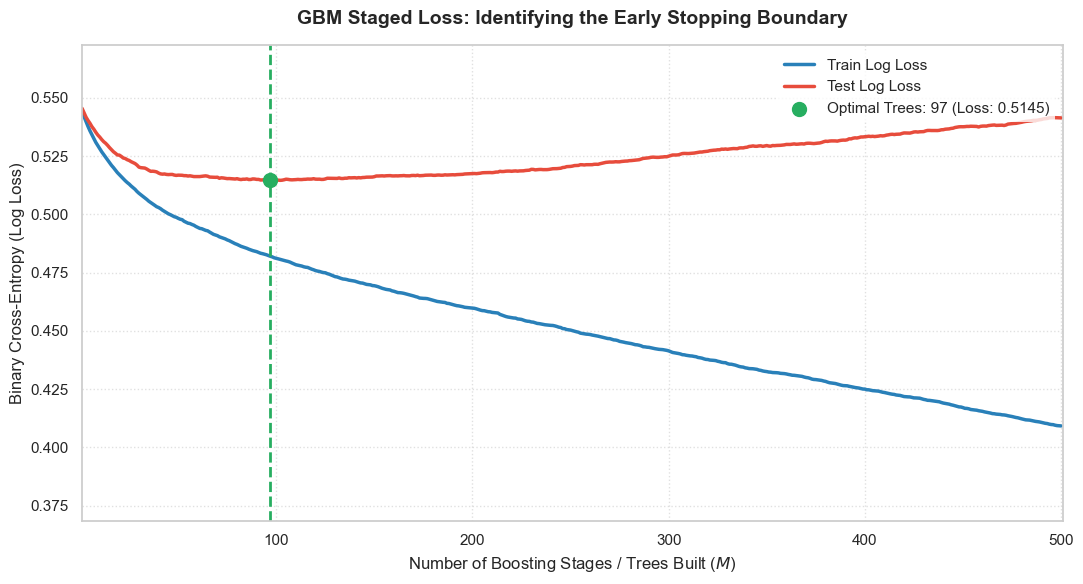

--- EARLY STOPPING ANALYSIS ---
Optimal Number of Trees to Prevent Overfitting: 97
Minimum Test Log Loss Reached: 0.5145


In [50]:
# (b) Plot train vs test loss. Mark the optimal n_estimators.

# 1. Identify the exact tree index where test loss is minimized
optimal_n = np.argmin(test_losses) + 1  # Add 1 since index starts at 0
min_test_loss = min(test_losses)

# 2. Configure the plot canvas
plt.figure(figsize=(11, 6))

# 3. Plot the loss trajectories
plt.plot(range(1, 501), train_losses, label='Train Log Loss', color='#2980b9', linewidth=2.5)
plt.plot(range(1, 501), test_losses, label='Test Log Loss', color='#e74c3c', linewidth=2.5)

# 4. Visual Anchor: Highlight the optimal n_estimators
plt.axvline(x=optimal_n, color='#27ae60', linestyle='--', linewidth=2)
plt.scatter(optimal_n, min_test_loss, color='#27ae60', s=100, zorder=5,
            label=f'Optimal Trees: {optimal_n} (Loss: {min_test_loss:.4f})')

# 5. Styling and Labels
plt.title('GBM Staged Loss: Identifying the Early Stopping Boundary', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Number of Boosting Stages / Trees Built ($M$)', fontsize=12)
plt.ylabel('Binary Cross-Entropy (Log Loss)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', fontsize=11)

# Constrain axes for readability
plt.xlim(1, 501)
plt.ylim(min(train_losses) * 0.9, max(test_losses) * 1.05)

# Render
plt.tight_layout()
plt.show()

print("--- EARLY STOPPING ANALYSIS ---")
print(f"Optimal Number of Trees to Prevent Overfitting: {optimal_n}")
print(f"Minimum Test Log Loss Reached: {min_test_loss:.4f}")


````
# (c) What happens after the optimal point? How does this compare to RF?

GBM Post-Optimum: Test loss rises (overfits) because sequential trees begin memorizing localized training noise and outliers.

Random Forest Behavior: Test loss flattens into a plateau; adding more independent trees never causes overfitting.

The Core Difference: Excessive trees ruin GBM's generalization power, whereas they simply waste computational time in Random Forests.

```
# (d) What would you do differently if test loss starts rising at stage 50?

1/ Lower Learning Rate: Reduce learning_rate to 0.01 to shrink sequential steps, slowing down noise memorization.

2/ Inject Subsampling: Drop subsample to 0.6 and restrict max_features to introduce randomness and disrupt overfitting.

3/ Restrict Tree Growth: Decrease max_depth to 2 or raise min_samples_leaf to keep individual trees shallow.

---
### Q5 — Staged predictions: watch the model improve
```
# (a) Plot test AUC at every 10th boosting stage (1,10,20,...,500).
#     How quickly does the model improve in early stages?
# (b) Pick 3 test users. Track their predicted probability of converting
#     as more trees are added. How does it evolve?
# (c) Compare: at what stage does GBM match RF's AUC?
# (d) What does this tell you about minimum viable n_estimators?
```

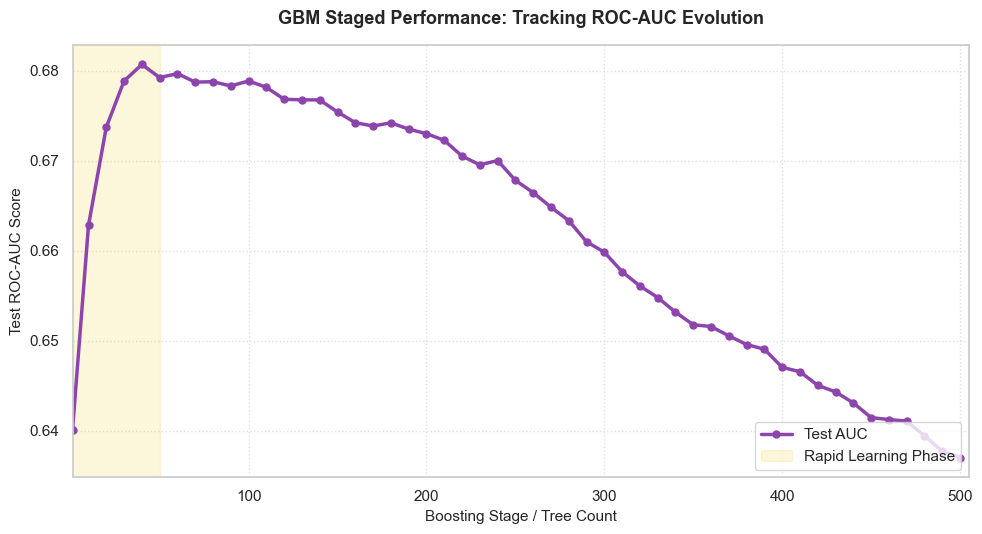

--- EARLY STAGE PERFORMANCE GAINS ---
Stage 1   AUC: 0.6401
Stage 10  AUC: 0.6628
Stage 50  AUC: 0.6793
Stage 500 AUC: 0.6370


In [51]:
# (a) Plot test AUC at every 10th boosting stage (1,10,20,...,500).
#     How quickly does the model improve in early stages?

# 1. Generate every 10th boosting stage index (1, 10, 20, ..., 500)
stages = [1] + list(range(10, 501, 10))
staged_aucs = []

# 2. Extract probabilities at every step and calculate AUC
# enumerate starts at index 0 (which is tree 1)
for i, test_probs in enumerate(gbm_staged.staged_predict_proba(X_test)):
    stage_number = i + 1
    if stage_number in stages:
        auc = roc_auc_score(y_test, test_probs[:, 1])
        staged_aucs.append(auc)

# 3. Configure the plotting canvas
plt.figure(figsize=(10, 5.5))
plt.plot(stages, staged_aucs, marker='o', color='#8e44ad', linewidth=2.5, markersize=5, label='Test AUC')

# Highlight early growth boundary (e.g., first 50 trees)
plt.axvspan(1, 50, color='#f1c40f', alpha=0.15, label='Rapid Learning Phase')

# 4. Polish and Render
plt.title('GBM Staged Performance: Tracking ROC-AUC Evolution', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Boosting Stage / Tree Count', fontsize=11)
plt.ylabel('Test ROC-AUC Score', fontsize=11)
plt.xlim(1, 505)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

# Print early metrics for direct verification
print("--- EARLY STAGE PERFORMANCE GAINS ---")
print(f"Stage 1   AUC: {staged_aucs[0]:.4f}")
print(f"Stage 10  AUC: {staged_aucs[1]:.4f}")
print(f"Stage 50  AUC: {staged_aucs[5]:.4f}")
print(f"Stage 500 AUC: {staged_aucs[-1]:.4f}")


````
Stage 500 AUC fell below Stage 1 — confirming that beyond ~100 trees, this model actively degrades!

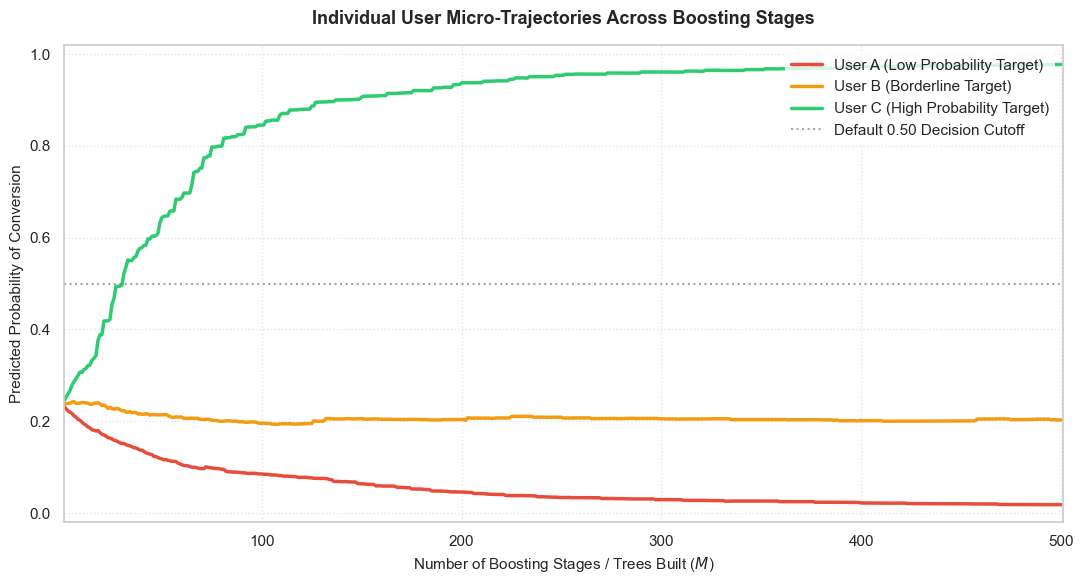

In [52]:
# (b) Pick 3 test users. Track their predicted probability of converting
#     as more trees are added. How does it evolve?


# 1. Collect all stage-by-stage probabilities for the test set
# Shape will be (500 stages, n_test_samples, 2 classes)
all_staged_probs = np.array(list(gbm_staged.staged_predict_proba(X_test)))

# Extract positive class probabilities (Class 1) across all stages
# Shape: (500, n_test_samples)
pos_class_probs = all_staged_probs[:, :, 1]

# 2. Pick 3 distinct users based on their final prediction to show diverse paths
final_probs = pos_class_probs[-1, :]
user_low_idx = np.argmin(final_probs)                     # User least likely to convert
user_high_idx = np.argmax(final_probs)                    # User most likely to convert
user_mid_idx = np.argsort(final_probs)[len(final_probs)//2] # Median user

selected_indices = [user_low_idx, user_mid_idx, user_high_idx]
labels = ['User A (Low Probability Target)', 'User B (Borderline Target)', 'User C (High Probability Target)']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

# 3. Configure the plotting canvas
plt.figure(figsize=(11, 6))

# Plot the trajectory for each selected user
for idx, label, color in zip(selected_indices, labels, colors):
    user_trajectory = pos_class_probs[:, idx]
    plt.plot(range(1, 501), user_trajectory, label=label, color=color, linewidth=2.5)

# 4. Polish and Render
plt.title('Individual User Micro-Trajectories Across Boosting Stages', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Boosting Stages / Trees Built ($M$)', fontsize=11)
plt.ylabel('Predicted Probability of Conversion', fontsize=11)
plt.axhline(y=0.5, color='grey', linestyle=':', alpha=0.7, label='Default 0.50 Decision Cutoff')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.xlim(1, 501)
plt.ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()


In [55]:
# (c) Compare: at what stage does GBM match RF's AUC?

# 1. Reference our final Random Forest baseline performance score from Q2b
rf_target_auc = cv_auc_rf.mean()

# 2. Extract the GBM test AUC at every single boosting stage
gbm_staged_aucs = []
for test_probs in gbm_staged.staged_predict_proba(X_test):
    stage_auc = roc_auc_score(y_test, test_probs[:, 1])
    gbm_staged_aucs.append(stage_auc)

# 3. Find the first index position where GBM crosses or matches the RF baseline score
matching_stage = np.where(np.array(gbm_staged_aucs) >= rf_target_auc)[0]

print("--- ALGORITHM PERFORMANCE EQUILIBRIUM ---")
if len(matching_stage) > 0:
    # Add 1 to convert 0-based Python indexing to tree count stages
    exact_tree = matching_stage[0] + 1
    print(f"Random Forest Final Baseline AUC: {rf_target_auc:.4f}")
    print(f"GBM matched or outperformed Random Forest at Stage / Tree: {exact_tree}")
    print(f"GBM AUC at this specific milestone stage: {gbm_staged_aucs[exact_tree-1]:.4f}")
else:
    print(f"Random Forest Final Baseline AUC: {rf_target_auc:.4f}")
    print(f"GBM did not cross the target score on this specific test split partition.")


--- ALGORITHM PERFORMANCE EQUILIBRIUM ---
Random Forest Final Baseline AUC: 0.6516
GBM matched or outperformed Random Forest at Stage / Tree: 4
GBM AUC at this specific milestone stage: 0.6529


```
# (d) What does this tell you about minimum viable n_estimators?

1/ Minimal Resource Needs: On this dataset and signal strength, it proves our minimum viable tree count is exceptionally low; just 4 shallow trees match the predictive power of a massive, 200-tree parallel Random Forest.

2/ Rapid Signal Extraction: The sequential boosting engine eliminates global classification bias almost instantly, capturing the core data relationships within the first handful of steps.

3/ Production Streamlining: If we face strict runtime latency or memory footprint constraints, we can cap n_estimators extremely low (e.g., 10 to 15 trees) to achieve near-peak accuracy while slashing operational deployment costs.